DATA INSPECTION

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("cyberbullying_tweets.csv")
data

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying
...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity
47688,Turner did not withhold his disappointment. Tu...,ethnicity
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [13]:
data.describe()

,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,RT @sailorhg: the intro for my hardware hackin...,religion
freq,2,7998


In [14]:
print(data.isnull().sum())

tweet_text            0
cyberbullying_type    0
dtype: int64


In [15]:
print(data["tweet_text"].duplicated().sum())

1675


In [16]:
duplicates = data[data["tweet_text"].duplicated(keep=False)]
duplicates

,tweet_text,cyberbullying_type
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
8,@stockputout everything but mostly my priest,not_cyberbullying
17,@0xabad1dea @kelseytheodore2 twitter is basica...,not_cyberbullying
24,Wishing my arena partner was on. &gt;.&gt; Re...,not_cyberbullying
27,@gcarothers eek. i can't stand split keyboards...,not_cyberbullying
...,...,...
46360,RT @AntonioFrench: I spent the morning at the ...,ethnicity
46556,"He can't be a server at our restaurant, that b...",ethnicity
46915,Racism won't stop as long as u stil select ur ...,ethnicity
46962,"Still, Davis, who is gay, said he pays a socia...",ethnicity


In [17]:
filtered_data = data.drop_duplicates(subset="tweet_text", keep="first")

In [18]:
filtered_data.shape

(46017, 2)

In [10]:
class_counts = filtered_data["cyberbullying_type"].value_counts()
class_counts

cyberbullying_type
religion               7995
age                    7992
ethnicity              7952
not_cyberbullying      7937
gender                 7898
other_cyberbullying    6243
Name: count, dtype: int64

C:\Users\bhush\AppData\Local\Temp\ipykernel_17000\210881006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = filtered_data, x = "cyberbullying_type" , palette = "viridis")


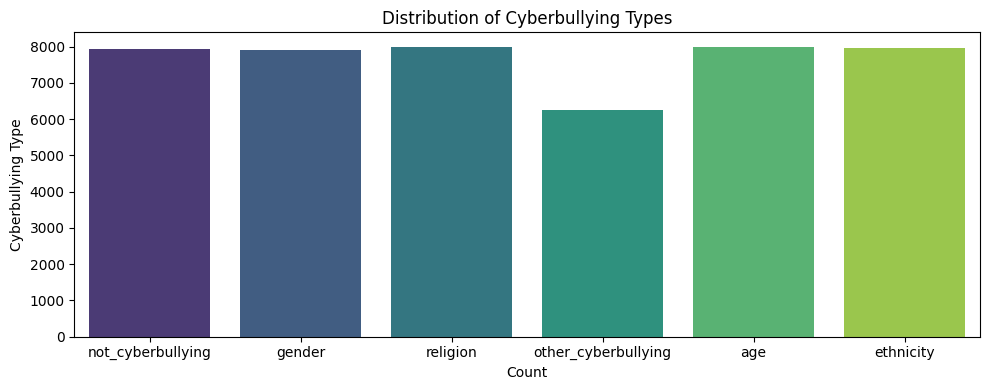

In [15]:
import seaborn as sns

plt.figure(figsize=(10,4))
sns.countplot(data = filtered_data, x = "cyberbullying_type" , palette = "viridis")
plt.title("Distribution of Cyberbullying Types")
plt.xlabel("Count")
plt.ylabel("Cyberbullying Type")
plt.tight_layout()
plt.show()


DATA PREPROCESSING

In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
nltk.download("stopwords")
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhush\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhush\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [10]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [11]:
def process_data(text):
    text = str(text).lower()
    
    text = re.sub(r"http\S+|www\S+" , " " , text)
    
    text = re.sub(r"@\w+" , " " , text)
    
    text = re.sub(r"[^a-z\s]" , " " , text)
    
    words = text.split()
    
    cleaned_words = [
        lemmatizer.lemmatize(word) for word in words if word not in stop_words
    ]
    
    return " ".join(cleaned_words)

    

In [19]:
filtered_data

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying
...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity
47688,Turner did not withhold his disappointment. Tu...,ethnicity
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity


In [20]:
filtered_data["processed_text"] = filtered_data["tweet_text"].apply(process_data)


C:\Users\bhush\AppData\Local\Temp\ipykernel_17784\4058079184.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["processed_text"] = filtered_data["tweet_text"].apply(process_data)


In [21]:
filtered_data

,tweet_text,cyberbullying_type,processed_text
0,"In other words #katandandre, your food was cra...",not_cyberbullying,word katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,classy whore red velvet cupcake
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,meh p thanks head concerned another angry dude...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,isi account pretending kurdish account like is...
...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,black ppl expected anything depended anything ...
47688,Turner did not withhold his disappointment. Tu...,ethnicity,turner withhold disappointment turner called c...
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,swear god dumb nigger bitch got bleach hair re...
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,yea fuck rt youre nigger fucking unfollow fuck...


In [28]:
filtered_data.to_csv("cleaned_tweets.csv" , index=False)

In [31]:
df = pd.read_csv("cleaned_tweets.csv")
print(df["processed_text"])

0                   word katandandre food crapilicious mkr
1        aussietv white mkr theblock imacelebrityau tod...
2                          classy whore red velvet cupcake
3        meh p thanks head concerned another angry dude...
4        isi account pretending kurdish account like is...
                               ...                        
46012    black ppl expected anything depended anything ...
46013    turner withhold disappointment turner called c...
46014    swear god dumb nigger bitch got bleach hair re...
46015    yea fuck rt youre nigger fucking unfollow fuck...
46016    bro u gotta chill rt dog fuck kp dumb nigger b...
Name: processed_text, Length: 46017, dtype: object
